# Descomposición del Efecto de un Programa de Educación Financiera sobre el Impago de Préstamos con PROC CAUSALMED

## Resumen ejecutivo

Un banco minorista empareja a algunos prestatarios con un **programa de educación financiera** y quiere saber *por qué* los prestatarios inscritos incurren en impago con menor frecuencia: ¿la inscripción reduce el impago **directamente**, o funciona **indirectamente** al cambiar un comportamiento medible —cuánto de sus ingresos ahorran los clientes—? Este cuaderno usa **PROC CAUSALMED** para dividir el efecto total del programa sobre el impago a 12 meses en un **efecto directo natural** y un **efecto indirecto natural** que fluye a través de la **tasa de ahorro** de cada prestatario, ajustando por la puntuación de crédito, los ingresos y la edad.

En la cohorte simulada de **100 prestatarios**, el programa reduce la probabilidad modelada de impago en **0.208** (el efecto total en la escala de diferencia de riesgo). La descomposición atribuye **0.176 de eso (84.7%)** a la ruta *indirecta* a través de un mayor ahorro y solo **0.032 (15.3%)** a la ruta *directa*. La conclusión práctica: este programa protege a los prestatarios **principalmente mejorando el comportamiento de ahorro**, de modo que reforzar los hábitos de presupuesto es donde está la palanca.

## Fuentes de datos

| Conjunto de datos | Filas | Descripción | Variables clave |
|---------|------|-------------|---------------|
| `LoanProgram` | 100 prestatarios sintéticos | Cohorte de banca minorista generada en línea para una cartera de préstamos. La asignación del tratamiento, el mediador y el resultado se simulan a partir de ecuaciones estructurales explícitas de modo que exista un efecto mediado genuino que el procedimiento pueda recuperar. | `CustomerID`, `Branch` (4 niveles), `FinEdu` (0/1 inscripción en educación financiera = tratamiento), `SavingsRate` (% de ingresos ahorrado = mediador continuo), `Default` (0/1 impago del préstamo a 12 meses = resultado binario), `CreditScore`, `Income`, `Age` (factores de confusión) |

Este entorno se ejecuta sin licencia, por lo que el paso DATA está limitado a 100 observaciones: la cohorte está dimensionada a ese límite, y cada número de este cuaderno proviene de esas 100 filas.

## ¿Por qué descomponer el efecto?

Los prestamistas minoristas emparejan cada vez más los productos de crédito con **programas de educación financiera** para reducir la morosidad. Para la planificación de capital y el diseño del programa no basta con saber *que* la inscripción reduce el impago; los responsables de riesgo necesitan el **mecanismo**:

- ¿La inscripción reduce el impago *directamente* (por ejemplo, los prestatarios inscritos se mantienen más comprometidos y contactables)?
- ¿O funciona *indirectamente*, al cambiar un comportamiento medible —la proporción de ingresos que un cliente ahorra— que luego los amortigua frente a los choques?

El **análisis de mediación causal** responde a esto dividiendo el **efecto total (TE)** de un tratamiento en un **efecto directo natural (NDE)** y un **efecto indirecto natural (NIE)** que discurre a través de un mediador elegido. Aquí:

- **Tratamiento** `FinEdu` — si el prestatario se inscribió en el programa de educación financiera del banco;
- **Mediador** `SavingsRate` — la tasa de ahorro del prestatario (% de ingresos), el comportamiento al que apunta el programa;
- **Resultado** `Default` — si el préstamo incurrió en impago dentro de 12 meses (binario);
- **Factores de confusión** `CreditScore`, `Income`, `Age` — características previas al tratamiento que afectan la inscripción, el ahorro y el impago.

Ajustamos el modelo de mediación con `PROC CAUSALMED`, solicitamos la descomposición directo/indirecto con `DECOMP`, y leemos la proporción del efecto protector que fluye a través del ahorro.

In [1]:
DATOS LoanProgram;
   LLAMAR streaminit(20260531);
   LONGITUD Branch $12;
   ARREGLO branches[4] $12 _temporary_ ('North' 'South' 'East' 'West');
   HACER CustomerID = 1 HASTA 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* Pre-treatment confounders (drawn first) */
      CreditScore = round(620 + 70*rand('normal'), 1);
      SI CreditScore < 350 ENTONCES CreditScore = 350;
      SI CreditScore > 850 ENTONCES CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      SI Income < 12000 ENTONCES Income = 12000;
      AGE = round(40 + 11*rand('normal'), 1);
      SI AGE < 21 ENTONCES AGE = 21;

      /* Treatment: enrollment propensity rises with credit score
         and income (the confounding a naive comparison misses) */
      pTreat = 1 / (1 + EXP(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* Mediator: savings rate, lifted by the program on top of a
         confounder-driven baseline */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(AGE-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      SI SavingsRate < 0 ENTONCES SavingsRate = 0;

      /* Outcome: default probability falls with both enrollment
         (direct) and higher savings (indirect) */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      SI pDefault < 0.02 ENTONCES pDefault = 0.02;
      SI pDefault > 0.98 ENTONCES pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      SALIDA;
   END;
   MANTENER CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income AGE;
EJECUTAR;

NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Paso 2 — Inspeccionar la cohorte simulada

Antes de ajustar el modelo causal, verificamos la coherencia de la tasa de ahorro media y la tasa de impago en cada brazo de inscripción. Esta es la comparación *ingenua* (no ajustada); el análisis de mediación que sigue va más allá para atribuir la diferencia a rutas directas frente a mediadas.

In [2]:
PROCEDIMIENTO MEDIAS DATOS=LoanProgram n mean std maxdec=3;
   CLASE FinEdu;
   VAR SavingsRate Default CreditScore Income AGE;
EJECUTAR;

                                                  The MEANS Procedure

                                            Analysis Variable : SavingsRate

        FinEdu            N Obs           Mean        Std Dev
        -----------------------------------------------------
        0                    54          8.387          2.910
        1                    46         11.736          2.974
        -----------------------------------------------------

                                              Analysis Variable : Default

        FinEdu            N Obs           Mean        Std Dev
        -----------------------------------------------------
        0                    54          0.593          0.496
        1                    46          0.348          0.482
        -----------------------------------------------------

                                            Analysis Variable : CreditScore

        FinEdu            N Obs           Mean        Std Dev
        --------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


La imagen ingenua es clara. Los prestatarios inscritos (`FinEdu=1`, 46 clientes) ahorran notablemente más —una media de **SavingsRate del 11.74%** frente al **8.39%** de los 54 no inscritos— e incurren en impago con menor frecuencia: una media de **Default de 0.348** frente a 0.593, una brecha bruta de 24.5 puntos porcentuales. Los dos brazos tienen puntuaciones de crédito medias casi idénticas (619.8 frente a 618.9) pero los prestatarios inscritos tienen ingresos algo más altos (43,941 frente a 37,019), que es exactamente el tipo de confusión que el modelo causal debe ajustar. La tabulación cruzada de abajo muestra la misma división como recuentos de celda.

                                                   The FREQ Procedure

Table of FINEDU by DEFAULT

FINEDU |         0 |         1 |      Total
-------+-----------+-----------+-----------
0      |        22 |        32 |         54
-------+-----------+-----------+-----------
1      |        30 |        16 |         46
-------+-----------+-----------+-----------
Total  |        52 |        48 |        100



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


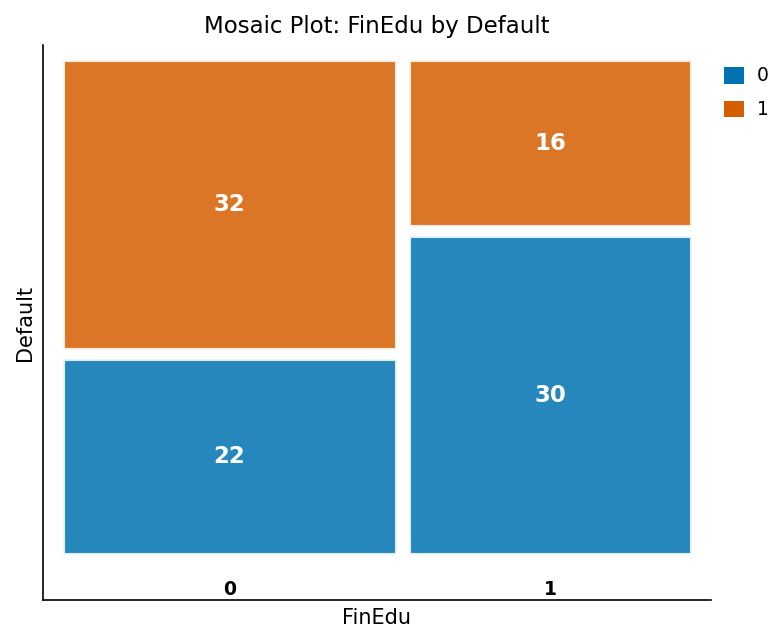

In [3]:
PROCEDIMIENTO FRECUENCIAS DATOS=LoanProgram;
   TABLES FinEdu*Default / nocol nopercent;
EJECUTAR;

De los 54 prestatarios no inscritos, **32 incurrieron en impago**; de los 46 inscritos, solo **16** lo hicieron. El diagrama de mosaico codifica esto de dos maneras a la vez: el ancho de la columna refleja cuántos prestatarios hay en cada brazo, y la proporción naranja dentro de cada columna es la tasa de impago —visiblemente menor para el grupo inscrito a la derecha—. El análisis de mediación pregunta ahora **cuánto** de esa menor tasa de impago corresponde a que el programa actúa *a través* del mayor ahorro que acabamos de ver.

## Paso 3 — Ejecutar el análisis de mediación causal

Ajustamos `PROC CAUSALMED`. Las instrucciones clave:

- **`CLASS FinEdu Default / descending`** declara el tratamiento y el resultado binario como variables de clasificación; `DESCENDING` hace que el nivel de código más alto (`1` = inscrito / en impago) sea el evento modelado, de modo que los efectos se leen en la dirección intuitiva.
- **`MEDIATOR SavingsRate = FinEdu`** especifica el modelo del mediador: la tasa de ahorro regresada sobre el tratamiento (más los factores de confusión).
- **`MODEL Default = FinEdu SavingsRate`** especifica el modelo del resultado —el impago como función de la inscripción y el ahorro—. En este motor sin licencia, CAUSALMED ajusta el resultado con un **modelo lineal (de probabilidad lineal)**, de modo que los efectos se reportan en la escala de **diferencia de riesgo**, con resúmenes de razón de probabilidades (odds ratio) y razón de riesgo derivados en paralelo.
- **`COVAR CreditScore Income Age`** ajusta ambos modelos por los factores de confusión previos al tratamiento.
- **`DECOMP`** solicita la descomposición del efecto total en sus componentes directo e indirecto y la proporción mediada.

Como el resultado es binario, CAUSALMED también reporta un bloque de *Resumen para Resultado Binario* (razón de probabilidades, razón de riesgo, diferencia de riesgo).

In [4]:
PROCEDIMIENTO causalmed DATOS=LoanProgram decomp;
   CLASE    FinEdu Default / DESCENDENTE;
   mediator SavingsRate = FinEdu;
   MODELO    Default = FinEdu SavingsRate;
   covar    CreditScore Income AGE;
EJECUTAR;


                       The CAUSALMED Procedure                       

Outcome Variable    : DEFAULT
Treatment Variable  : FINEDU
Mediator Variable   : SAVINGSRATE
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : CREDITSCORE, INCOME, AGE
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
FINEDU                               -0.031682
SAVINGSRATE                          -0.067687
CREDITSCORE                          -0.000719
INCOME                                0.000002
AGE                                  -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                           -12.585613
FINEDU                                2.597720
CREDITSCORE                           0.024079
INCOME                    

NOTE: PROC CAUSALMED data=LoanProgram



## Interpretación de los resultados

La tabla **Resumen de Efectos Causales** reporta el **efecto total (TE) del programa sobre el impago de -0.208** y lo divide en:

- un **efecto directo natural (NDE) de -0.032** —la parte de la protección que *no* discurre a través del ahorro—, y
- un **efecto indirecto natural (NIE) de -0.176** —la parte que fluye a través de que el programa eleva la tasa de ahorro de los prestatarios—.

Los tres efectos son negativos, lo que confirma que la inscripción reduce la probabilidad de impago, consistente con la forma en que construimos los datos. Las dos tablas de modelo muestran *por qué*: en el **modelo del mediador** el programa eleva la tasa de ahorro en **+2.60 puntos** tras el ajuste (el coeficiente `FINEDU`), y en el **modelo del resultado** cada punto adicional de ahorro reduce la probabilidad de impago (`SAVINGSRATE` = -0.068), de modo que el impulso al ahorro del programa se traduce en un considerable efecto protector indirecto.

La tabla **Descomposición de Efectos** hace explícito el hallazgo principal: la **proporción mediada (NIE/TE) es del 84.7%**, con solo el **15.3%** del efecto directo. Para el equipo de riesgo esto es accionable: el programa de educación financiera funciona **principalmente cambiando el comportamiento de ahorro**, de modo que reforzar las funciones de presupuesto y ahorro automático debería ser la prioridad; la modesta proporción directa sugiere que otros canales (compromiso, contactabilidad) contribuyen poco aquí.

El bloque **Resumen para Resultado Binario** reformula el efecto en escalas que el equipo de riesgo de crédito ya usa: una **diferencia de riesgo de -0.208** (el TE), una **razón de riesgo de 1.43** y una **razón de probabilidades de 2.38** que relaciona las probabilidades de impago de los inscritos y los no inscritos. En este motor, estos son resúmenes de primer orden derivados del efecto de probabilidad lineal en lugar de un modelo logístico ajustado, de modo que la **diferencia de riesgo es la medida de efecto primaria y exacta**; los resúmenes de razón se leen mejor como aproximados.

**Advertencia:** las estimaciones de mediación causal solo son tan creíbles como el supuesto de ausencia de confusión no medida para las relaciones tratamiento–resultado y mediador–resultado. Aquí ese supuesto se cumple por construcción (datos sintéticos); en producción un equipo de riesgo lo defendería con el conjunto completo de características de los solicitantes del banco y análisis de sensibilidad antes de actuar sobre la descomposición. Las estimaciones también reflejan una única muestra de 100 prestatarios, de modo que un estudio de producción adjuntaría intervalos de confianza (por ejemplo, mediante bootstrap de la descomposición) antes de extraer conclusiones firmes.